/Users/subratotapaswi/Documents/Forecasting/Project/venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



 ARIMAX Predictions (First 10) 

        date  actual_return  predicted_return  lower_bound  upper_bound
0 2024-08-08       0.010387          0.000366    -0.021742     0.022475
1 2024-08-09      -0.000841         -0.004505    -0.026613     0.017604
2 2024-08-12      -0.008543          0.002906    -0.019203     0.025014
3 2024-08-13       0.000197          0.001260    -0.020848     0.023369
4 2024-08-14       0.016460          0.000705    -0.021403     0.022814
5 2024-08-16       0.001284          0.000974    -0.021134     0.023083
6 2024-08-19       0.005136         -0.000671    -0.022779     0.021438
7 2024-08-20       0.002889          0.001642    -0.020466     0.023751
8 2024-08-21       0.001667          0.003217    -0.018892     0.025325
9 2024-08-22       0.000470          0.003063    -0.019045     0.025171

 ARIMAX Predictions (Last 10) 

          date  actual_return  predicted_return  lower_bound  upper_bound
360 2026-03-13       0.011131          0.000500    -0.021608     0.

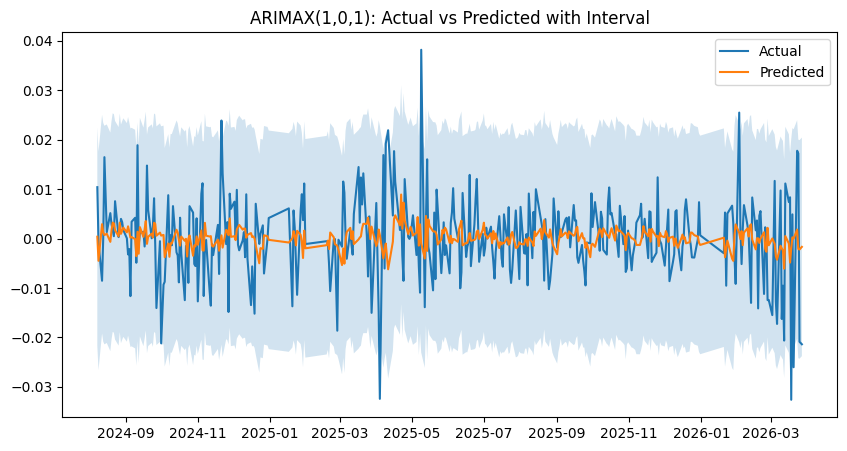

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# LOAD DATA
df = pd.read_csv("nifty_final_dataset.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

# TARGET
y = df["target"]

# SELECT FEATURES (X)
selected_features = [
    "log_ret_lag1",
    "log_ret_lag2",
    
    "bank_ret", "it_ret", "pharma_ret", "auto_ret",
    "fmcg_ret", "metal_ret", "energy_ret",
    
    "bank_ret_lag1", "it_ret_lag1", "pharma_ret_lag1",
    "auto_ret_lag1", "fmcg_ret_lag1", "metal_ret_lag1", "energy_ret_lag1",
    
    "vol_5", "vol_15",
    "momentum",
    "rsi"
]

X = df[selected_features]

# TRAIN TEST SPLIT
split = int(len(df) * 0.8)

y_train, y_test = y[:split], y[split:]
X_train, X_test = X[:split], X[split:]
test_dates = df["date"][split:]

# MODEL: ARIMAX(1,0,1)
model = ARIMA(y_train, order=(1,0,1), exog=X_train).fit()

forecast = model.get_forecast(steps=len(y_test), exog=X_test)

pred = forecast.predicted_mean
conf = forecast.conf_int()

lower = conf.iloc[:, 0]
upper = conf.iloc[:, 1]

# RESULTS TABLE
results_df = pd.DataFrame({
    "date": test_dates.values,
    "actual_return": y_test.values,
    "predicted_return": pred.values,
    "lower_bound": lower.values,
    "upper_bound": upper.values
})

print("\n ARIMAX Predictions (First 10) \n")
print(results_df.head(10))

print("\n ARIMAX Predictions (Last 10) \n")
print(results_df.tail(10))

# METRICS
rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

picp = np.mean((y_test >= lower) & (y_test <= upper))
mpiw = np.mean(upper - lower)

print("\n ARIMAX Metrics n")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
print("PICP:", picp)
print("MPIW:", mpiw)

# SAVE
results_df.to_csv("ARIMAX_predictions.csv", index=False)

# PLOT
plt.figure(figsize=(10,5))
plt.plot(results_df["date"], results_df["actual_return"], label="Actual")
plt.plot(results_df["date"], results_df["predicted_return"], label="Predicted")

plt.fill_between(
    results_df["date"],
    results_df["lower_bound"],
    results_df["upper_bound"],
    alpha=0.2
)

plt.title("ARIMAX(1,0,1): Actual vs Predicted with Interval")
plt.legend()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# FUNCTION TO COMPUTE METRICS
def compute_metrics(file, model_name):
    df = pd.read_csv(file)
    
    y_true = df["actual_return"]
    y_pred = df["predicted_return"]
    lower = df["lower_bound"]
    upper = df["upper_bound"]
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    picp = np.mean((y_true >= lower) & (y_true <= upper))
    mpiw = np.mean(upper - lower)
    
    return [model_name, rmse, mae, r2, picp, mpiw]

# LOAD ALL MODELS
results = []

results.append(compute_metrics("AR_predictions.csv", "AR"))
results.append(compute_metrics("MA_predictions.csv", "MA"))
results.append(compute_metrics("ARMA_1_1_predictions.csv", "ARMA"))
results.append(compute_metrics("ARIMA_1_0_1_predictions.csv", "ARIMA"))
results.append(compute_metrics("ARIMAX_predictions.csv", "ARIMAX"))

# CREATE FINAL TABLE
final_df = pd.DataFrame(results, columns=[
    "Model", "RMSE", "MAE", "R2", "PICP", "MPIW"
])

# PRINT
print("\n FINAL MODEL COMPARISON \n")
print(final_df)


 FINAL MODEL COMPARISON 

    Model      RMSE       MAE        R2      PICP      MPIW
0      AR  0.008272  0.006064 -0.002474  0.983784  0.044923
1      MA  0.008272  0.006064 -0.002527  0.983784  0.044904
2    ARMA  0.008272  0.006063 -0.002366  0.983784  0.044900
3   ARIMA  0.008272  0.006063 -0.002366  0.983784  0.044900
4  ARIMAX  0.008470  0.006329 -0.050903  0.981081  0.044217
